# 01 — A neural network from scratch (in NumPy)

Code companion to [`../neural-networks.md`](../neural-networks.md).

**Goal**: build a small multi-layer perceptron (MLP) using only NumPy and develop intuition for what a forward pass actually is — just matrix multiplies and a non-linearity. We won't train it yet (that's notebook 02).

By the end you'll be able to:
- Initialise a small network's weights
- Run a forward pass and inspect what each layer outputs
- See why an *untrained* network's predictions are random nonsense
- Quantify "how wrong" with cross-entropy loss

New to Jupyter? Read [`NOTEBOOKS.md`](NOTEBOOKS.md) first.

## Setup

We only need `numpy` for matrices and `matplotlib` for plotting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducible runs

## A toy problem: two moons

Classify points in 2D into two classes shaped like interlocking moons — *not* linearly separable, so a simple straight-line classifier won't work. We'll need a real network.

X shape: (200, 2)    y shape: (200,)


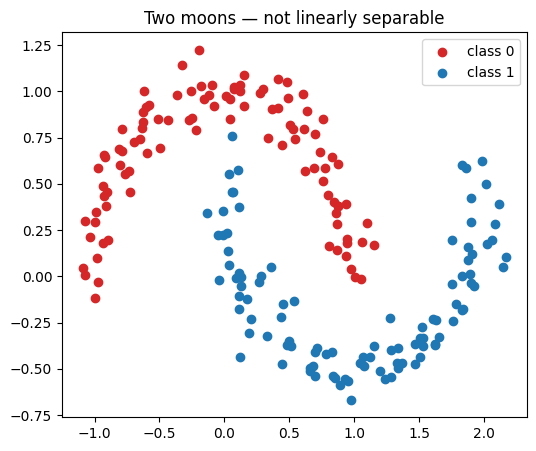

In [2]:
def make_moons(n=200, noise=0.1):
    n_per = n // 2
    theta = np.linspace(0, np.pi, n_per)

    # Upper moon (class 0)
    x0 = np.stack([np.cos(theta), np.sin(theta)], axis=1)

    # Lower moon (class 1) — mirrored and shifted
    x1 = np.stack([1 - np.cos(theta), 1 - np.sin(theta) - 0.5], axis=1)

    X = np.concatenate([x0, x1], axis=0)
    X += noise * np.random.randn(*X.shape)
    y = np.concatenate([np.zeros(n_per), np.ones(n_per)]).astype(int)
    return X, y

X, y = make_moons(200)
print("X shape:", X.shape, "   y shape:", y.shape)

plt.figure(figsize=(6, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c="tab:red",  label="class 0")
plt.scatter(X[y==1, 0], X[y==1, 1], c="tab:blue", label="class 1")
plt.legend()
plt.title("Two moons — not linearly separable")
plt.show()

## Defining the network

We'll build an MLP with shape `2 → 16 → 16 → 2`:
- Input: a 2D point
- Two hidden layers of 16 neurons each
- Output: 2 logits (one per class)

Each layer is just `h = activation(x @ W.T + b)`. Stacked:

```
h1     = ReLU(x  @ W1.T + b1)
h2     = ReLU(h1 @ W2.T + b2)
logits =      h2 @ W3.T + b3
```

Note the last layer has no activation — we'll apply softmax separately to turn logits into probabilities.

We use **He initialisation** (`scale = sqrt(2/in_dim)`), a sensible default for ReLU networks. Too-large initial weights make activations explode; too-small ones make them vanish.

In [3]:
def init_params(layer_sizes):
    """Initialise weights and biases for a list of layer sizes.

    e.g. [2, 16, 16, 2] gives weight matrices of shape (16, 2), (16, 16), (2, 16).
    """
    params = []
    for in_dim, out_dim in zip(layer_sizes[:-1], layer_sizes[1:]):
        W = np.random.randn(out_dim, in_dim) * np.sqrt(2.0 / in_dim)
        b = np.zeros(out_dim)
        params.append((W, b))
    return params

params = init_params([2, 16, 16, 2])
for i, (W, b) in enumerate(params, start=1):
    print(f"Layer {i}: W shape {W.shape}, b shape {b.shape}")

Layer 1: W shape (16, 2), b shape (16,)
Layer 2: W shape (16, 16), b shape (16,)
Layer 3: W shape (2, 16), b shape (2,)


## Activation and softmax

**ReLU**: `max(0, x)` applied elementwise. Cheap and effective; the modern default.

**Softmax**: turns the output logits into probabilities that sum to 1. We subtract the max first for numerical stability — `exp` of a large number overflows.

```
softmax(z)_i = exp(z_i) / sum_j exp(z_j)
```

In [4]:
def relu(x):
    return np.maximum(0, x)

def softmax(logits):
    shifted = logits - logits.max(axis=-1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=-1, keepdims=True)

# Quick sanity check
print("ReLU([-1, 0, 1, 2]) =", relu(np.array([-1, 0, 1, 2])))
p = softmax(np.array([[1.0, 2.0, 3.0]]))
print("softmax([1, 2, 3]) =", p, "  sums to", p.sum())

ReLU([-1, 0, 1, 2]) = [0 0 1 2]
softmax([1, 2, 3]) = [[0.09003057 0.24472847 0.66524096]]   sums to 0.9999999999999999


## The forward pass

Compose the layers. Input flows through linear-then-ReLU layers, with the final layer being linear-only (logits).

In [5]:
def forward(params, x):
    """Forward pass. x: (N, in_dim) batch of inputs. Returns logits: (N, out_dim)."""
    h = x
    for W, b in params[:-1]:
        h = relu(h @ W.T + b)
    W, b = params[-1]
    return h @ W.T + b  # logits, no activation

logits = forward(params, X)
probs = softmax(logits)

print("logits shape:", logits.shape)
print("first 3 logits:\n", logits[:3])
print("first 3 probs:\n", probs[:3])
print("row sums (should be ~1.0):", probs[:3].sum(axis=1))

logits shape: (200, 2)
first 3 logits:
 [[1.08187569 0.5928734 ]
 [1.22205545 0.51861673]
 [1.03786327 0.52844137]]
first 3 probs:
 [[0.61987137 0.38012863]
 [0.66894974 0.33105026]
 [0.62467094 0.37532906]]
row sums (should be ~1.0): [1. 1. 1.]


## What does an *untrained* network see?

Since we haven't trained the weights, the decision surface is essentially random. Let's visualise it: for every point in a grid, ask the network what class it predicts, and colour by `P(class = 1)`.

What you'll see is *some* boundary — but not the right one.

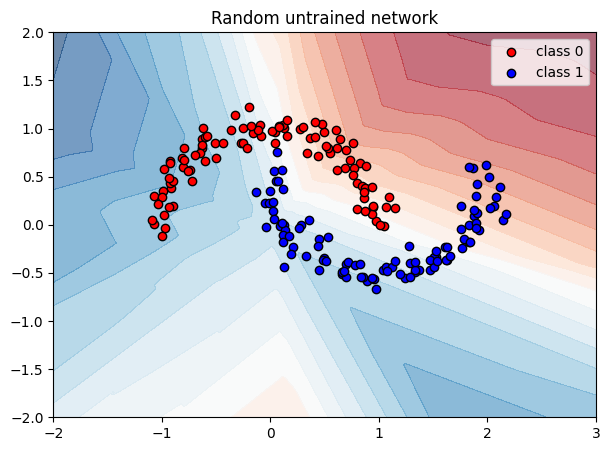

In [6]:
def plot_decision_surface(params, X, y, title=""):
    xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-2, 2, 200))
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1)
    grid_probs = softmax(forward(params, grid))
    p_class1 = grid_probs[:, 1].reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, p_class1, levels=20, cmap="RdBu", alpha=0.6)
    plt.scatter(X[y==0, 0], X[y==0, 1], c="red",  edgecolor="k", label="class 0")
    plt.scatter(X[y==1, 0], X[y==1, 1], c="blue", edgecolor="k", label="class 1")
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_surface(params, X, y, title="Random untrained network")

## Quantifying "how wrong"

Cross-entropy loss measures the gap between predicted probabilities and true labels:

```
L = - mean( log( probability assigned to the correct class ) )
```

If the network always predicted the right class with probability 1, loss = 0. A coin flip on a 2-class problem gives `-log(0.5) ≈ 0.693`. Anything *worse* than that means the network is below random.

Why log? It heavily punishes confident wrong answers (`log(0.001)` is much more negative than `log(0.4)`). It's also what falls naturally out of maximum-likelihood estimation — see the theory doc.

In [7]:
def cross_entropy(probs, y):
    n = len(y)
    correct_class_probs = probs[np.arange(n), y]
    return -np.mean(np.log(correct_class_probs + 1e-12))  # +eps to avoid log(0)

loss = cross_entropy(probs, y)
print(f"Initial loss:          {loss:.4f}")
print(f"Random-guess baseline: {-np.log(0.5):.4f}")

Initial loss:          0.7460
Random-guess baseline: 0.6931


## What's next

Right now the network is random. To make it useful we need to:
1. Compute the gradient of loss w.r.t. every weight
2. Nudge each weight a bit in the direction that decreases loss
3. Repeat

→ `02-gradient-descent.ipynb` does (1) and (2) the slow-but-clear way (numerical gradients). `03-micrograd-style.ipynb` does it the *correct* way (analytical gradients via backpropagation).

## Exercises

1. Change layer sizes to `[2, 4, 2]` (one tiny hidden layer). Re-run from `init_params` onward. Does the random decision boundary look different?
2. Try `np.random.seed(0)`, `np.random.seed(7)`, etc. The boundary changes shape but always looks random.
3. Replace `relu` with `np.tanh` in `forward`. What changes about the decision surface? (Hint: tanh outputs in (-1, 1), not [0, ∞).)
4. Multiply the initial weights by 100 (`W = ... * 100` inside `init_params`). What happens to the predicted probabilities and why? (Hint: look at the logits.)
5. Try a deeper net: `[2, 16, 16, 16, 16, 2]`. Does the loss change much before training? Why might *adding depth* not help an untrained network?